In [1]:
# Importo librerias necesarias para analisis y modelado
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import *
import streamlit as st
import holidays

In [2]:
# Cargo los dataframes de ventas y competencia desde los archivos CSV
ventas = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
competencia = pd.read_csv('../data/raw/entrenamiento/competencia.csv')

# Muestro las dimensiones de cada dataframe
print(f"Ventas shape: {ventas.shape}")
print(f"Competencia shape: {competencia.shape}")

Ventas shape: (3552, 10)
Competencia shape: (3552, 5)


In [3]:
# Muestro las primeras filas del dataframe de ventas
ventas.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [4]:
# Muestro las primeras filas del dataframe de competencia
competencia.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [5]:
# Valido la calidad de datos del dataframe ventas
print("=== INFORME DE CALIDAD DE DATOS - VENTAS ===\n")

# 1. Tipos de datos
print("--- TIPOS DE DATOS ---")
print(ventas.dtypes)

# 2. Valores nulos
print("\n--- VALORES NULOS ---")
print(ventas.isnull().sum())

# 3. Filas duplicadas
print("\n--- FILAS DUPLICADAS ---")
print(f"Total duplicados: {ventas.duplicated().sum()}")

# 4. Estadisticos descriptivos
print("\n--- ESTADISTICOS DESCRIPTIVOS ---")
print(ventas.describe())

=== INFORME DE CALIDAD DE DATOS - VENTAS ===

--- TIPOS DE DATOS ---
fecha                 object
producto_id           object
nombre                object
categoria             object
subcategoria          object
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

--- VALORES NULOS ---
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64

--- FILAS DUPLICADAS ---
Total duplicados: 0

--- ESTADISTICOS DESCRIPTIVOS ---
       precio_base  unidades_vendidas  precio_venta      ingresos
count  3552.000000         3552.00000   3552.000000   3552.000000
mean    123.125000            4.87866    121.816546    605.972323
std     165.576753            6.31102    164.017963   1079.071192
min      20.0000

In [6]:
# Valido la calidad de datos del dataframe competencia
print("=== INFORME DE CALIDAD DE DATOS - COMPETENCIA ===\n")

# 1. Tipos de datos
print("--- TIPOS DE DATOS ---")
print(competencia.dtypes)

# 2. Valores nulos
print("\n--- VALORES NULOS ---")
print(competencia.isnull().sum())

# 3. Filas duplicadas
print("\n--- FILAS DUPLICADAS ---")
print(f"Total duplicados: {competencia.duplicated().sum()}")

# 4. Estadisticos descriptivos
print("\n--- ESTADISTICOS DESCRIPTIVOS ---")
print(competencia.describe())

=== INFORME DE CALIDAD DE DATOS - COMPETENCIA ===

--- TIPOS DE DATOS ---
fecha            object
producto_id      object
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object

--- VALORES NULOS ---
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

--- FILAS DUPLICADAS ---
Total duplicados: 0

--- ESTADISTICOS DESCRIPTIVOS ---
            Amazon    Decathlon  Deporvillage
count  3552.000000  3552.000000   3552.000000
mean    118.623407   111.412182    118.894628
std     156.095628   148.508132    160.216448
min      16.850000    15.450000     16.770000
25%      47.117500    43.285000     47.310000
50%      73.180000    66.285000     72.700000
75%     114.342500   111.172500    114.985000
max     858.350000   867.337500    932.325000


In [7]:
# Convierto la columna fecha a datetime en ambos dataframes
ventas['fecha'] = pd.to_datetime(ventas['fecha'])
competencia['fecha'] = pd.to_datetime(competencia['fecha'])

print("Fecha convertida a datetime en ambos dataframes")
print(f"Ventas fecha dtype: {ventas['fecha'].dtype}")
print(f"Competencia fecha dtype: {competencia['fecha'].dtype}")

Fecha convertida a datetime en ambos dataframes
Ventas fecha dtype: datetime64[ns]
Competencia fecha dtype: datetime64[ns]


In [8]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB


In [9]:
competencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 138.9+ KB


In [10]:
# Uno los dataframes de ventas y competencia usando fecha y producto_id como claves
df = pd.merge(ventas, competencia, on=['fecha', 'producto_id'], how='inner')

print(f"Dataframe unificado shape: {df.shape}")
df.head()

Dataframe unificado shape: (3552, 13)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


In [11]:
# Muestro la estructura del dataframe unificado df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
 10  Amazon             3552 non-null   float64       
 11  Decathlon          3552 non-null   float64       
 12  Deporvillage       3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(5), int64(2), object(4)


In [12]:
# Extraigo caracteristicas temporales de la fecha para el analisis
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek
df['nombre_dia'] = df['fecha'].dt.day_name()

# Defino Black Fridays (noviembre)
df['es_black_friday'] = (df['mes'] == 11) & (df['dia'] >= 22) & (df['dia'] <= 30)

print("Features temporales creadas")
print(f"Años en los datos: {df['año'].unique()}")
print(f"Black Fridays: {df['es_black_friday'].sum()} registros")

Features temporales creadas
Años en los datos: [2021 2022 2023 2024]
Black Fridays: 864 registros


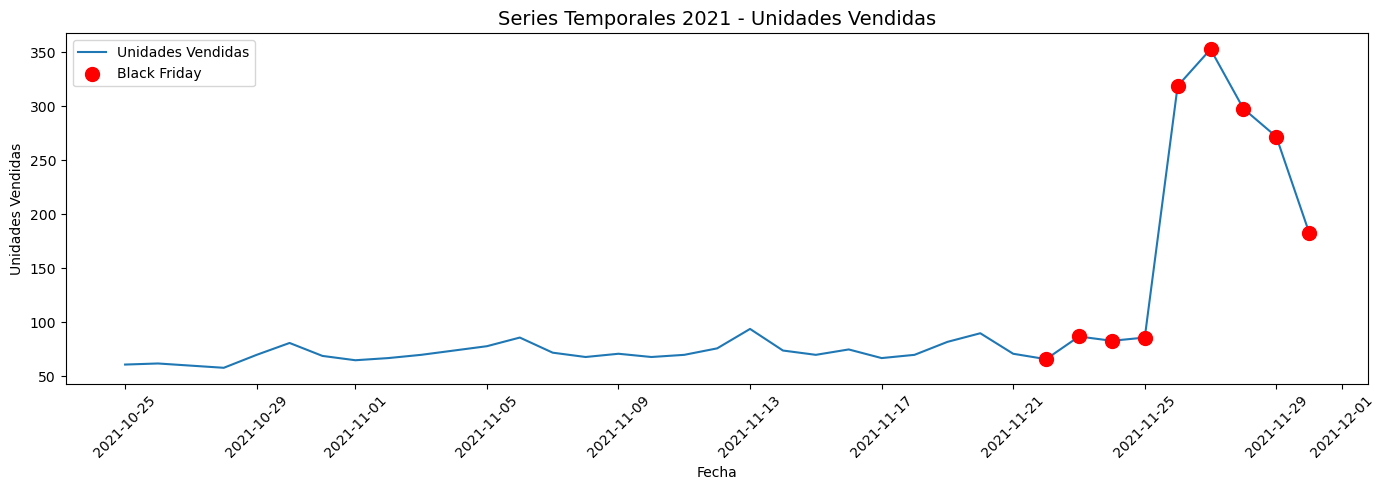

In [13]:
# Grafico de series temporales de unidades vendidas por año
# Agrego las ventas diarias
ventas_diarias = df.groupby('fecha')['unidades_vendidas'].sum().reset_index()
ventas_diarias['año'] = ventas_diarias['fecha'].dt.year
ventas_diarias['dia_semana'] = ventas_diarias['fecha'].dt.dayofweek
ventas_diarias['es_black_friday'] = (ventas_diarias['fecha'].dt.month == 11) & (ventas_diarias['fecha'].dt.day >= 22)

# Grafico 2021
plt.figure(figsize=(14, 5))
ventas_2021 = ventas_diarias[ventas_diarias['año'] == 2021]
sns.lineplot(data=ventas_2021, x='fecha', y='unidades_vendidas', label='Unidades Vendidas')
# Marco los Black Fridays
bf_2021 = ventas_2021[ventas_2021['es_black_friday']]
plt.scatter(bf_2021['fecha'], bf_2021['unidades_vendidas'], color='red', s=100, zorder=5, label='Black Friday')
plt.title('Series Temporales 2021 - Unidades Vendidas', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

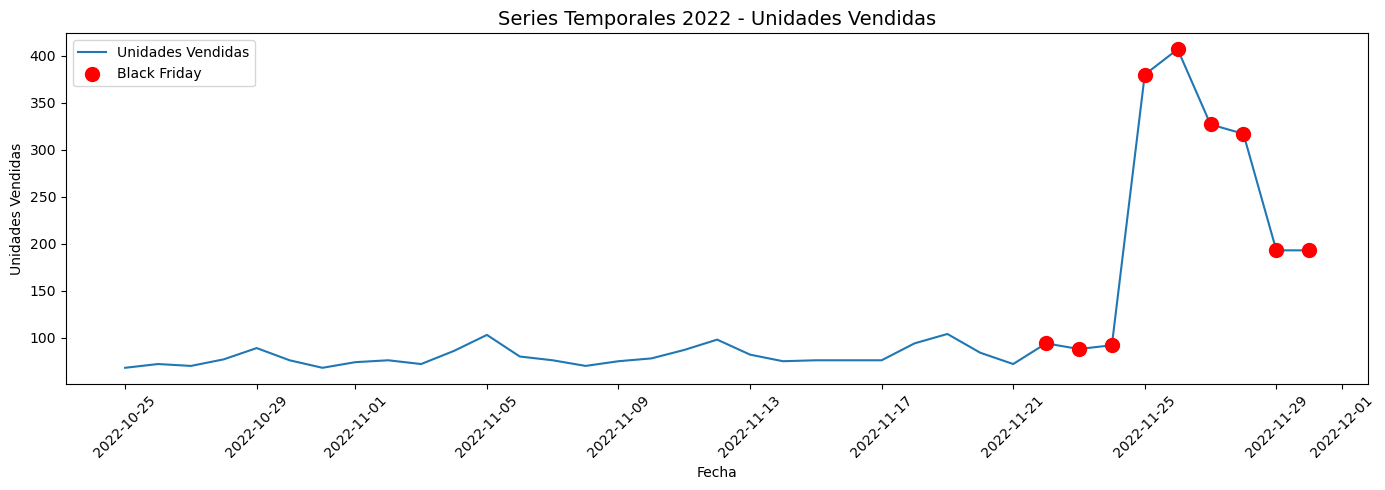

In [14]:
# Grafico 2022
plt.figure(figsize=(14, 5))
ventas_2022 = ventas_diarias[ventas_diarias['año'] == 2022]
sns.lineplot(data=ventas_2022, x='fecha', y='unidades_vendidas', label='Unidades Vendidas')
bf_2022 = ventas_2022[ventas_2022['es_black_friday']]
plt.scatter(bf_2022['fecha'], bf_2022['unidades_vendidas'], color='red', s=100, zorder=5, label='Black Friday')
plt.title('Series Temporales 2022 - Unidades Vendidas', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\m26344676\AppData\Local\Temp\ipykernel_19504\2595925975.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orden_dias, y=ventas_dia_semana.values, palette='Blues_d')


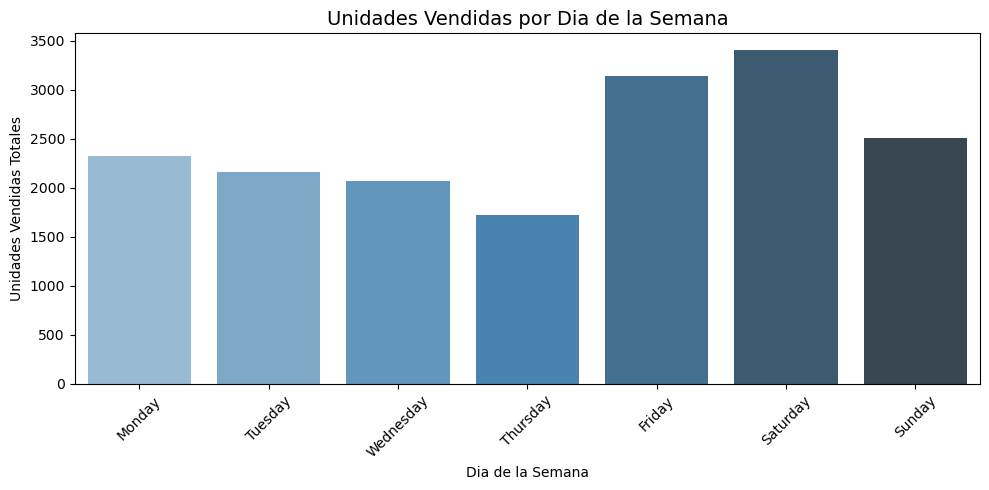

In [15]:
# Grafico de unidades vendidas por dia de la semana
plt.figure(figsize=(10, 5))
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_dia_semana = df.groupby('nombre_dia')['unidades_vendidas'].sum().reindex(orden_dias)
sns.barplot(x=orden_dias, y=ventas_dia_semana.values, palette='Blues_d')
plt.title('Unidades Vendidas por Dia de la Semana', fontsize=14)
plt.xlabel('Dia de la Semana')
plt.ylabel('Unidades Vendidas Totales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\m26344676\AppData\Local\Temp\ipykernel_19504\2810568349.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_categoria.index, y=ventas_categoria.values, palette='viridis')


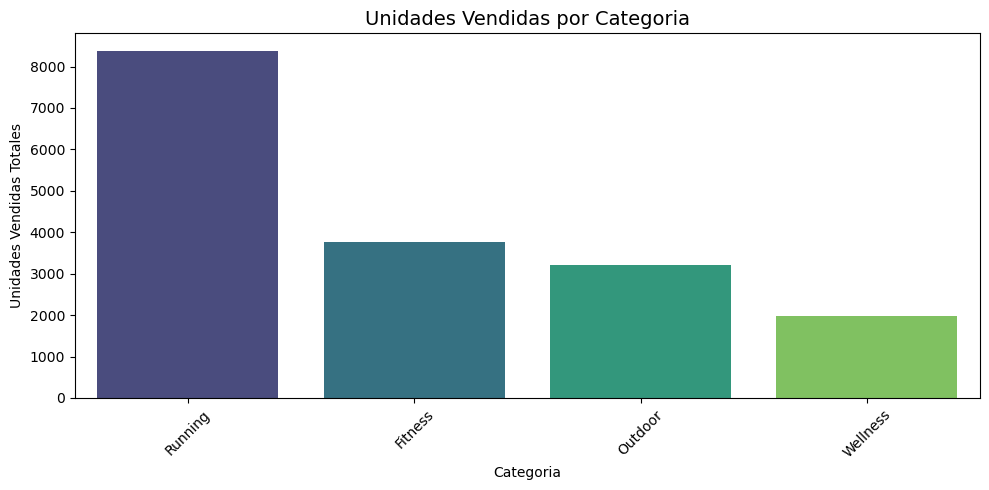

In [16]:
# Grafico de unidades vendidas por categoria
plt.figure(figsize=(10, 5))
ventas_categoria = df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False)
sns.barplot(x=ventas_categoria.index, y=ventas_categoria.values, palette='viridis')
plt.title('Unidades Vendidas por Categoria', fontsize=14)
plt.xlabel('Categoria')
plt.ylabel('Unidades Vendidas Totales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\m26344676\AppData\Local\Temp\ipykernel_19504\278243038.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_subcat.index, y=ventas_subcat.values, palette='coolwarm')


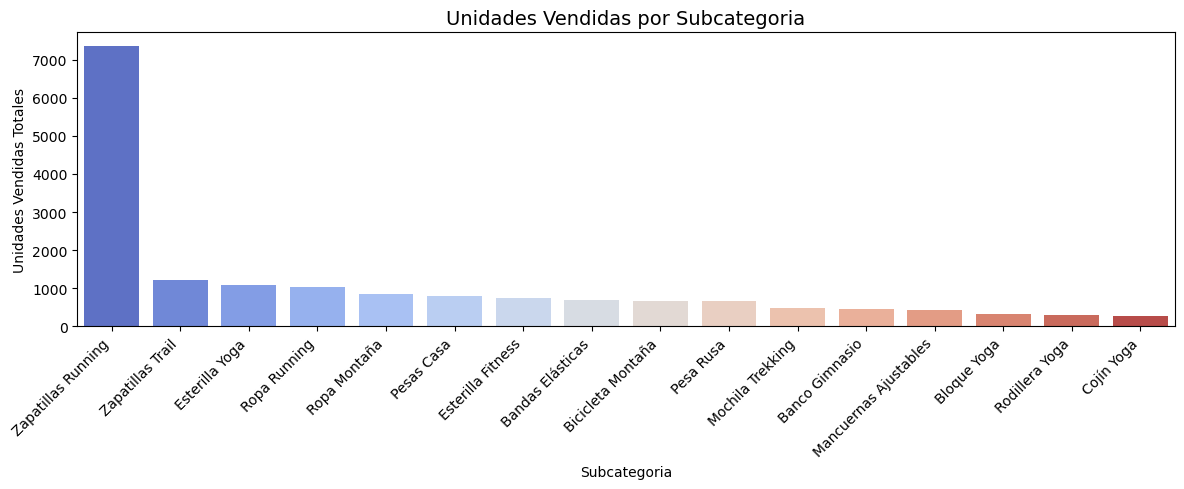

In [17]:
# Grafico de unidades vendidas por subcategoria
plt.figure(figsize=(12, 5))
ventas_subcat = df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False)
sns.barplot(x=ventas_subcat.index, y=ventas_subcat.values, palette='coolwarm')
plt.title('Unidades Vendidas por Subcategoria', fontsize=14)
plt.xlabel('Subcategoria')
plt.ylabel('Unidades Vendidas Totales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\m26344676\AppData\Local\Temp\ipykernel_19504\2436299520.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_productos.index, x=top_productos.values, palette='rocket')


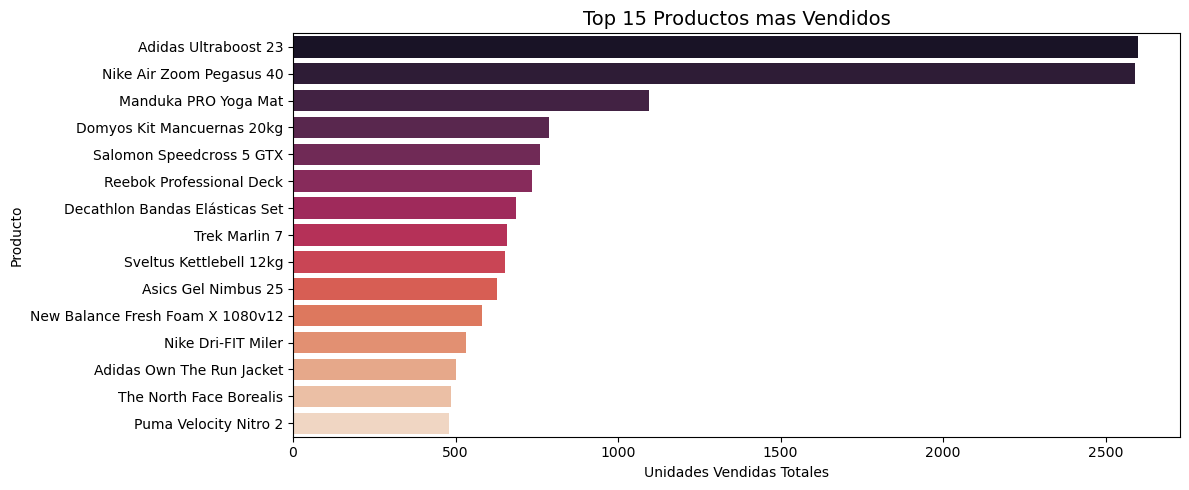

In [18]:
# Grafico de top 15 productos mas vendidos
plt.figure(figsize=(12, 5))
top_productos = df.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(15)
sns.barplot(y=top_productos.index, x=top_productos.values, palette='rocket')
plt.title('Top 15 Productos mas Vendidos', fontsize=14)
plt.xlabel('Unidades Vendidas Totales')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

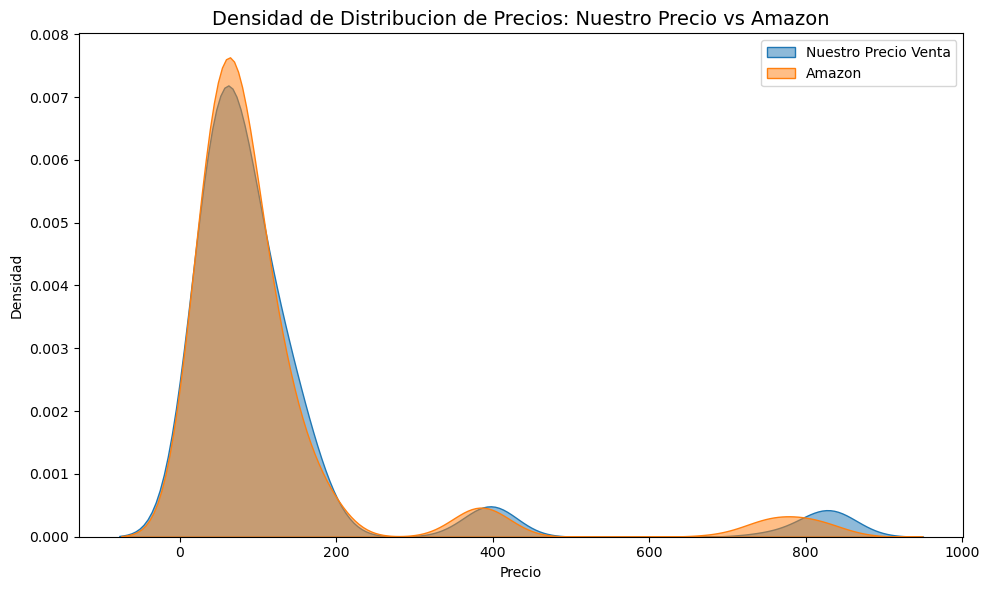

In [19]:
# Grafico de densidad de precios: nuestro precio vs Amazon
plt.figure(figsize=(10, 6))
sns.kdeplot(df['precio_venta'], label='Nuestro Precio Venta', fill=True, alpha=0.5)
sns.kdeplot(df['Amazon'], label='Amazon', fill=True, alpha=0.5)
plt.title('Densidad de Distribucion de Precios: Nuestro Precio vs Amazon', fontsize=14)
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Creo variables temporales y de calendario usando holidays de Espana
es_holidays = holidays.Spain(years=df['año'].unique())

# Variables temporales basicas
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek
df['semana_del_año'] = df['fecha'].dt.isocalendar().week
df['trimestre'] = df['fecha'].dt.quarter
df['dia_del_año'] = df['fecha'].dt.dayofyear

# Fin de semana (viernes 5, sabado 6, domingo 0)
df['es_fin_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

# Festivos de Espana
df['es_festivo'] = df['fecha'].isin(es_holidays).astype(int)

# Black Friday (4to jueves de noviembre)
from calendar import monthrange
def get_black_friday(year):
    nov = pd.date_range(start=f'{year}-11-01', periods=30, freq='D')
    thursday = [d for d in nov if d.weekday() == 3]
    return thursday[3] if len(thursday) > 3 else None

black_fridays = [get_black_friday(y) for y in df['año'].unique() if get_black_friday(y)]
df['es_black_friday'] = df['fecha'].isin(black_fridays).astype(int)

# Cyber Monday (lunes siguiente al Black Friday)
cyber_mondays = [bf + pd.Timedelta(days=3) for bf in black_fridays]
df['es_cyber_monday'] = df['fecha'].isin(cyber_mondays).astype(int)

# Comienzo y fin de mes
df['es_comienzo_mes'] = (df['dia_mes'] <= 5).astype(int)
df['es_fin_mes'] = (df['dia_mes'] >= 25).astype(int)

# Primer lunes del mes
def es_primer_lunes(row):
    primer_dia = pd.Timestamp(year=row['año'], month=row['mes'], day=1)
    primer_lunes = primer_dia + pd.Timedelta(days=(7 - primer_dia.weekday()) % 7)
    return 1 if row['fecha'] == primer_lunes else 0

df['es_primer_lunes_mes'] = df.apply(es_primer_lunes, axis=1)

# Rebajas de enero (1 al 31 de enero)
df['es_rebajas'] = ((df['mes'] == 1) & (df['dia_mes'] <= 31)).astype(int)

print("Variables temporales y de calendario creadas")
print(f"Festivos detectados: {df['es_festivo'].sum()}")
print(f"Black Fridays: {df['es_black_friday'].sum()}")
print(f"Cyber Mondays: {df['es_cyber_monday'].sum()}")

Variables temporales y de calendario creadas
Festivos detectados: 96
Black Fridays: 96
Cyber Mondays: 72


C:\Users\m26344676\AppData\Local\Temp\ipykernel_19504\1744720567.py:17: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['es_festivo'] = df['fecha'].isin(es_holidays).astype(int)


In [21]:
# Creo lags y media movil de unidades vendidas por producto y año
df = df.sort_values(['producto_id', 'fecha']).reset_index(drop=True)

lags = [1, 2, 3, 4, 5, 6, 7]
for lag in lags:
    df[f'lag_{lag}'] = df.groupby(['producto_id', 'año'])['unidades_vendidas'].shift(lag)

df['rolling_mean_7'] = df.groupby(['producto_id', 'año'])['unidades_vendidas'].transform(
    lambda x: x.rolling(window=7, min_periods=7).mean()
)

columnas_lags = [f'lag_{i}' for i in lags] + ['rolling_mean_7']
filas_antes = len(df)
df = df.dropna(subset=columnas_lags)
filas_despues = len(df)

print(f"Lags y media movil de 7 dias creados")
print(f"Registros antes: {filas_antes}")
print(f"Registros despues: {filas_despues}")
print(f"Registros eliminados: {filas_antes - filas_despues}")

Lags y media movil de 7 dias creados
Registros antes: 3552
Registros despues: 2880
Registros eliminados: 672


In [22]:
df.groupby('año').size()

año
2021    720
2022    720
2023    720
2024    720
dtype: int64

In [23]:
# Creo variable descuento porcentaje: diferencia entre precio venta y precio base
df['descuento_pct'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100

print(f"Variable descuento_pct creada")
print(f"Media descuento: {df['descuento_pct'].mean():.2f}%")
print(f"Min descuento: {df['descuento_pct'].min():.2f}%")
print(f"Max descuento: {df['descuento_pct'].max():.2f}%")

df.head()

Variable descuento_pct creada
Media descuento: -1.35%
Min descuento: -15.00%
Max descuento: 2.99%


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_rebajas,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean_7,descuento_pct
7,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,0,9.0,12.0,12.0,7.0,8.0,8.0,6.0,9.000000,0.060870
8,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,116.10,1161.00,...,0,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.285714,0.956522
9,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,114.58,1260.38,...,0,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.714286,-0.365217
10,2021-11-04,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,112.23,1346.76,...,0,11.0,10.0,7.0,9.0,12.0,12.0,7.0,10.428571,-2.408696
11,2021-11-05,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,113.81,1138.10,...,0,12.0,11.0,10.0,7.0,9.0,12.0,12.0,10.142857,-1.034783


In [24]:
# Creo variable precio_competencia como promedio de los competidores
df['precio_competencia'] = (df['Amazon'] + df['Decathlon'] + df['Deporvillage']) / 3

# Creo ratio_precio: nuestro precio entre precio promedio competencia
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']

# Elimino las columnas individuales de competencia
df = df.drop(columns=['Amazon', 'Decathlon', 'Deporvillage'])

print(f"Variables precio_competencia y ratio_precio creadas")
print(f"Columnas restantes: {df.shape[1]}")

Variables precio_competencia y ratio_precio creadas
Columnas restantes: 38


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2880 entries, 7 to 3551
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   fecha                2880 non-null   datetime64[ns]
 1   producto_id          2880 non-null   object        
 2   nombre               2880 non-null   object        
 3   categoria            2880 non-null   object        
 4   subcategoria         2880 non-null   object        
 5   precio_base          2880 non-null   int64         
 6   es_estrella          2880 non-null   bool          
 7   unidades_vendidas    2880 non-null   int64         
 8   precio_venta         2880 non-null   float64       
 9   ingresos             2880 non-null   float64       
 10  año                  2880 non-null   int32         
 11  mes                  2880 non-null   int32         
 12  dia                  2880 non-null   int32         
 13  dia_semana           2880 non-null   i

In [26]:
# Creo copias de nombre, categoria y subcategoria para one-hot encoding
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

# Aplico one-hot encoding solo a las 3 variables _h
df = pd.get_dummies(df, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], drop_first=False)

print(f"One-hot encoding aplicado")
print(f"Total columnas: {df.shape[1]}")

One-hot encoding aplicado
Total columnas: 82


In [27]:
# Guardo el dataframe procesado en data/processed
df.to_csv('../data/processed/df.csv', index=False)

print(f"Dataframe guardado en ../data/processed/df.csv")
print(f"Shape: {df.shape}")

Dataframe guardado en ../data/processed/df.csv
Shape: (2880, 82)


In [28]:
df.columns.tolist()

['fecha',
 'producto_id',
 'nombre',
 'categoria',
 'subcategoria',
 'precio_base',
 'es_estrella',
 'unidades_vendidas',
 'precio_venta',
 'ingresos',
 'año',
 'mes',
 'dia',
 'dia_semana',
 'nombre_dia',
 'es_black_friday',
 'dia_mes',
 'semana_del_año',
 'trimestre',
 'dia_del_año',
 'es_fin_semana',
 'es_festivo',
 'es_cyber_monday',
 'es_comienzo_mes',
 'es_fin_mes',
 'es_primer_lunes_mes',
 'es_rebajas',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_4',
 'lag_5',
 'lag_6',
 'lag_7',
 'rolling_mean_7',
 'descuento_pct',
 'precio_competencia',
 'ratio_precio',
 'nombre_h_Adidas Own The Run Jacket',
 'nombre_h_Adidas Ultraboost 23',
 'nombre_h_Asics Gel Nimbus 25',
 'nombre_h_Bowflex SelectTech 552',
 'nombre_h_Columbia Silver Ridge',
 'nombre_h_Decathlon Bandas Elásticas Set',
 'nombre_h_Domyos BM900',
 'nombre_h_Domyos Kit Mancuernas 20kg',
 'nombre_h_Gaiam Premium Yoga Block',
 'nombre_h_Liforme Yoga Pad',
 'nombre_h_Lotuscrafts Yoga Bolster',
 'nombre_h_Manduka PRO Yoga Mat',
 'nombre_h_M

In [29]:
# Divido df en train (2021-2023) y validation (2024)
train_df = df[df['año'].isin([2021, 2022, 2023])]
validation_df = df[df['año'] == 2024]

print(f"Train_df registros: {len(train_df)}")
print(f"Validation_df registros: {len(validation_df)}")

Train_df registros: 2160
Validation_df registros: 720


In [30]:
# Entreno HistGradientBoostingRegressor con parametros conservadores
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Defino target
target = 'unidades_vendidas'

# Selecciono features (excluyo fecha, ingresos y columnas object)
exclude_cols = ['fecha', 'ingresos', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'nombre_dia']
feature_cols = [col for col in df.columns if col not in exclude_cols and col != target]

X_train = train_df[feature_cols]
y_train = train_df[target]
X_val = validation_df[feature_cols]
y_val = validation_df[target]

# Modelo con parametros conservadores
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=500,
    max_depth=6,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42
)

model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_val)

# Baseline naive: media de entrenamiento
y_pred_baseline = [y_train.mean()] * len(y_val)

# Calculo metricas
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mae_model = mean_absolute_error(y_val, y_pred)
rmse_model = np.sqrt(mean_squared_error(y_val, y_pred))
mape_model = mape(y_val, y_pred)

mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_val, y_pred_baseline))
mape_baseline = mape(y_val, y_pred_baseline)

print('=== RESULTADOS MODELO vs BASELINE ===')
print(f'\nModelo HistGradientBoostingRegressor:')
print(f'  MAE:  {mae_model:.2f}')
print(f'  RMSE: {rmse_model:.2f}')
print(f'  MAPE: {mape_model:.2f}%')

print(f'\nBaseline (media):')
print(f'  MAE:  {mae_baseline:.2f}')
print(f'  RMSE: {rmse_baseline:.2f}')
print(f'  MAPE: {mape_baseline:.2f}%')

=== RESULTADOS MODELO vs BASELINE ===

Modelo HistGradientBoostingRegressor:
  MAE:  0.82
  RMSE: 1.62
  MAPE: 15.95%

Baseline (media):
  MAE:  3.67
  RMSE: 6.69
  MAPE: 93.02%


Productos estrella: 7


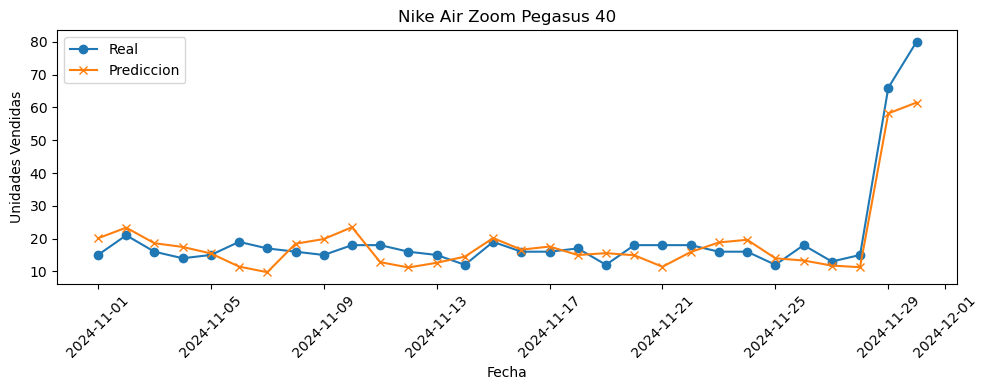

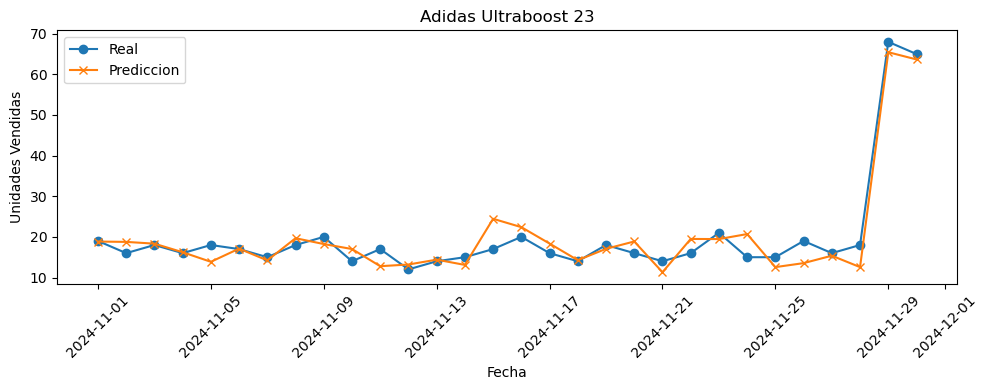

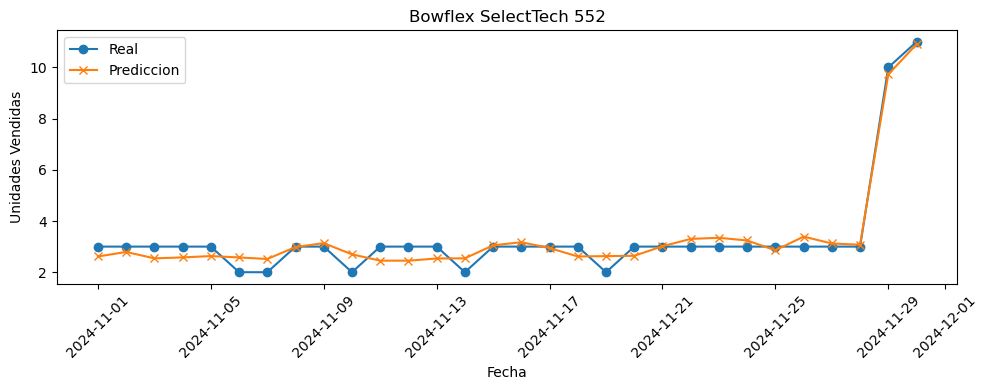

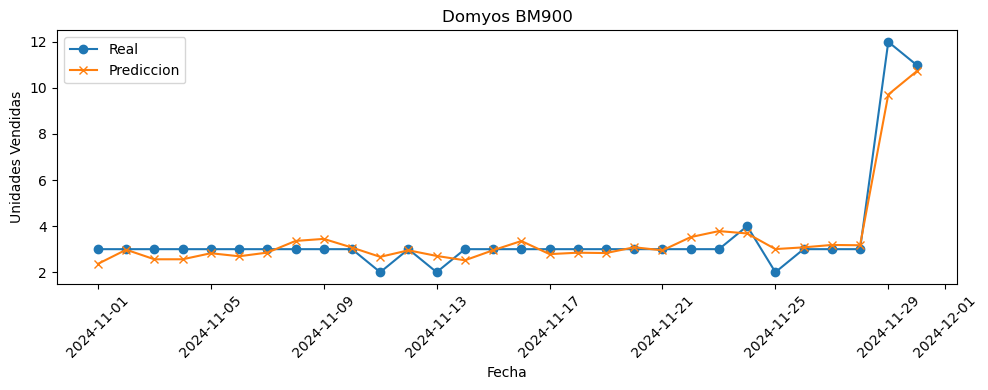

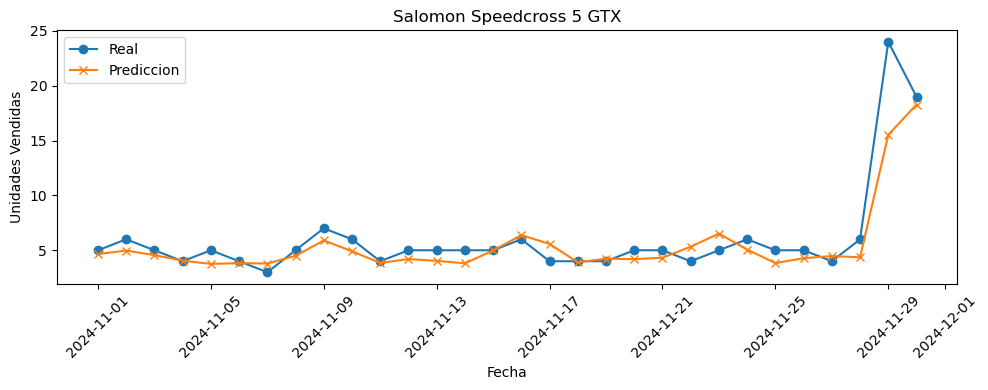

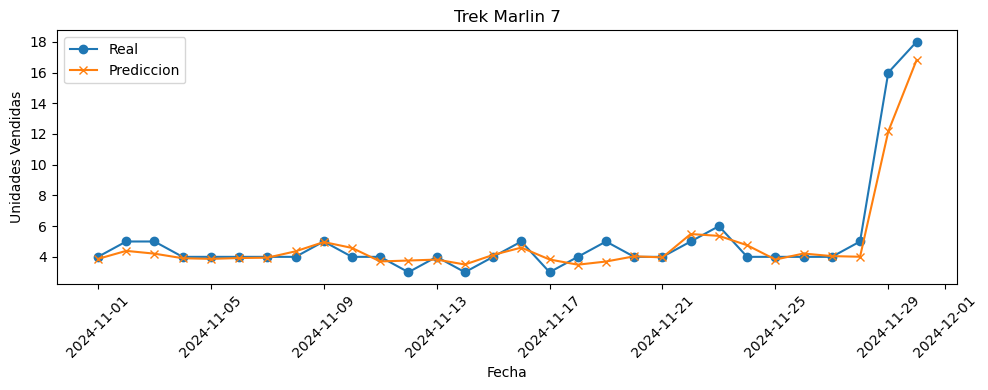

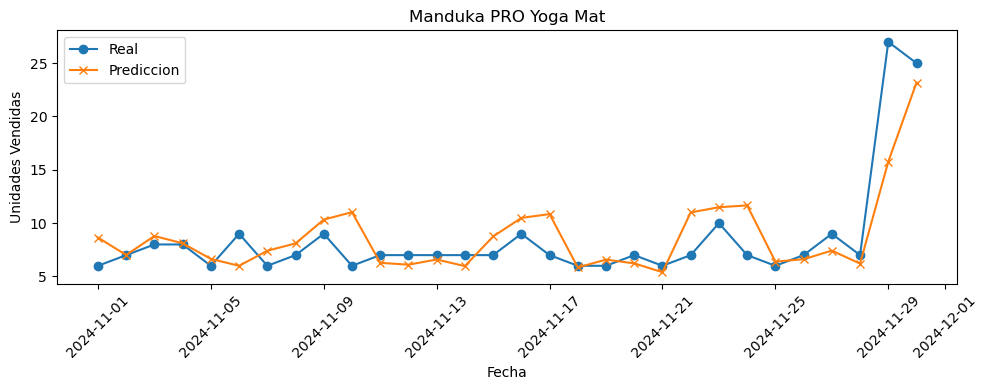

In [31]:
# Predicciones para noviembre 2024 por producto estrella
nov2024 = validation_df[(validation_df['mes'] == 11)]

productos_estrella = df[df['es_estrella'] == True]['nombre'].unique()
print(f'Productos estrella: {len(productos_estrella)}')

for producto in productos_estrella:
    prod_data = nov2024[nov2024['nombre'] == producto].sort_values('fecha')
    
    if len(prod_data) > 0:
        X_prod = prod_data[feature_cols]
        y_actual = prod_data[target].values
        y_pred_prod = model.predict(X_prod)
        
        plt.figure(figsize=(10, 4))
        plt.plot(prod_data['fecha'], y_actual, label='Real', marker='o')
        plt.plot(prod_data['fecha'], y_pred_prod, label='Prediccion', marker='x')
        plt.title(f'{producto}', fontsize=12)
        plt.xlabel('Fecha')
        plt.ylabel('Unidades Vendidas')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [32]:
# Calcular MAE para cada producto estrella
from sklearn.metrics import mean_absolute_error

mae_results = []
for producto in productos_estrella:
    prod_data = nov2024[nov2024["nombre"] == producto].sort_values("fecha")
    
    if len(prod_data) > 0:
        X_prod = prod_data[feature_cols]
        y_actual = prod_data[target].values
        y_pred_prod = model.predict(X_prod)
        
        mae = mean_absolute_error(y_actual, y_pred_prod)
        mae_results.append({"Producto": producto, "MAE": mae})
        print(f"{producto}: MAE = {mae:.2f}")

# DataFrame con resumen de MAE
mae_df = pd.DataFrame(mae_results).sort_values("MAE")
print("--- Resumen MAE ---")
mae_df

Nike Air Zoom Pegasus 40: MAE = 4.05
Adidas Ultraboost 23: MAE = 2.34
Bowflex SelectTech 552: MAE = 0.32
Domyos BM900: MAE = 0.39
Salomon Speedcross 5 GTX: MAE = 1.02
Trek Marlin 7: MAE = 0.54
Manduka PRO Yoga Mat: MAE = 1.82
--- Resumen MAE ---


,Producto,MAE
2,Bowflex SelectTech 552,0.318001
3,Domyos BM900,0.388479
5,Trek Marlin 7,0.539402
4,Salomon Speedcross 5 GTX,1.022744
6,Manduka PRO Yoga Mat,1.823466
1,Adidas Ultraboost 23,2.340033
0,Nike Air Zoom Pegasus 40,4.049157


=== Metricas por Periodo ===
          Periodo      MAE     RMSE      MAPE
 Periodo 1 (1-10) 0.652056 1.227049 15.147410
Periodo 2 (11-20) 0.612599 1.065626 16.167331
Periodo 3 (21-30) 1.207614 2.297952 16.530023


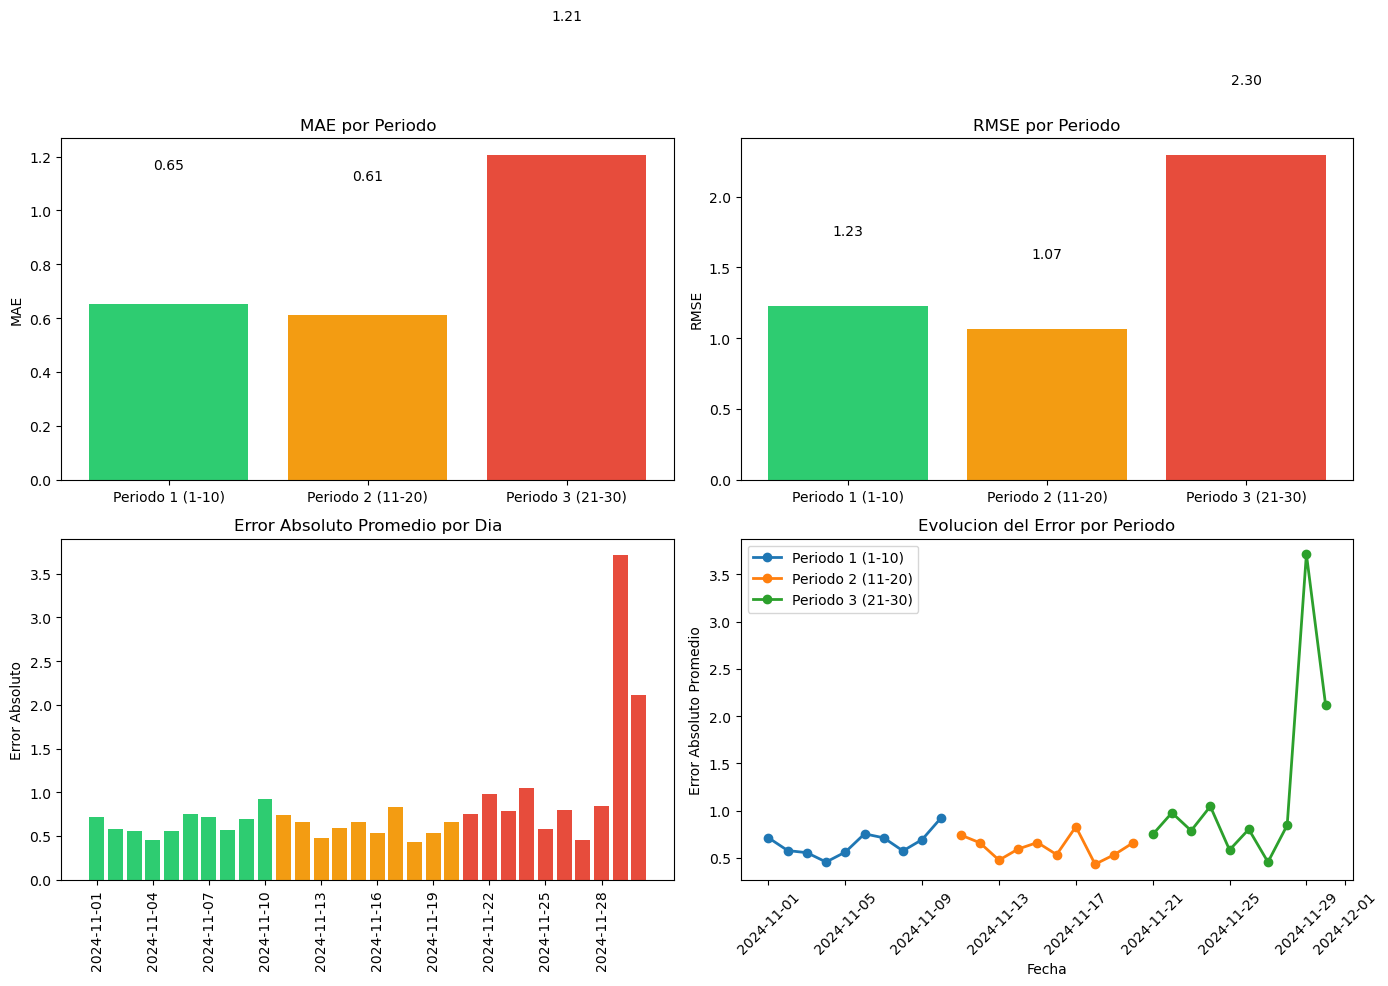

=== Analisis de Degradacion del Error ===
MAE Periodo 1: 0.65
MAE Periodo 3: 1.21
Degradacion: +85.2%


In [34]:
# Analisis de degradacion del error en noviembre 2024
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Dividir noviembre en 3 periodos de 10 dias
nov2024_sorted = nov2024.sort_values("fecha").copy()
nov2024_sorted["dia"] = nov2024_sorted["fecha"].dt.day

def asignar_periodo(dia):
    if dia <= 10:
        return "Periodo 1 (1-10)"
    elif dia <= 20:
        return "Periodo 2 (11-20)"
    else:
        return "Periodo 3 (21-30)"

nov2024_sorted["periodo"] = nov2024_sorted["dia"].apply(asignar_periodo)

# Predicciones para todo noviembre
X_nov = nov2024_sorted[feature_cols]
y_actual_nov = nov2024_sorted[target].values
y_pred_nov = model.predict(X_nov)
nov2024_sorted["prediccion"] = y_pred_nov
nov2024_sorted["error"] = np.abs(y_actual_nov - y_pred_nov)
nov2024_sorted["error_cuadrado"] = (y_actual_nov - y_pred_nov) ** 2

# Calcular metricas por periodo
metricas_periodo = []
for periodo in ["Periodo 1 (1-10)", "Periodo 2 (11-20)", "Periodo 3 (21-30)"]:
    periodo_data = nov2024_sorted[nov2024_sorted["periodo"] == periodo]
    mae = mean_absolute_error(periodo_data[target], periodo_data["prediccion"])
    rmse = np.sqrt(mean_squared_error(periodo_data[target], periodo_data["prediccion"]))
    mape = np.mean(np.abs((periodo_data[target] - periodo_data["prediccion"]) / periodo_data[target].replace(0, np.nan))) * 100
    metricas_periodo.append({"Periodo": periodo, "MAE": mae, "RMSE": rmse, "MAPE": mape})

metricas_df = pd.DataFrame(metricas_periodo)
print("=== Metricas por Periodo ===")
print(metricas_df.to_string(index=False))

# Graficar evolucion del error
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. MAE por periodo
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
axes[0, 0].bar(metricas_df["Periodo"], metricas_df["MAE"], color=colors)
axes[0, 0].set_title("MAE por Periodo", fontsize=12)
axes[0, 0].set_ylabel("MAE")
for i, v in enumerate(metricas_df["MAE"]):
    axes[0, 0].text(i, v + 0.5, f"{v:.2f}", ha="center", fontsize=10)

# 2. RMSE por periodo
axes[0, 1].bar(metricas_df["Periodo"], metricas_df["RMSE"], color=colors)
axes[0, 1].set_title("RMSE por Periodo", fontsize=12)
axes[0, 1].set_ylabel("RMSE")
for i, v in enumerate(metricas_df["RMSE"]):
    axes[0, 1].text(i, v + 0.5, f"{v:.2f}", ha="center", fontsize=10)

# 3. Error absoluto promedio por dia
error_diario = nov2024_sorted.groupby("fecha")["error"].mean().reset_index()
error_diario["periodo"] = error_diario["fecha"].dt.day.apply(asignar_periodo)
color_map = {"Periodo 1 (1-10)": "#2ecc71", "Periodo 2 (11-20)": "#f39c12", "Periodo 3 (21-30)": "#e74c3c"}
bar_colors = error_diario["periodo"].map(color_map)
axes[1, 0].bar(range(len(error_diario)), error_diario["error"], color=bar_colors)
axes[1, 0].set_title("Error Absoluto Promedio por Dia", fontsize=12)
axes[1, 0].set_ylabel("Error Absoluto")
axes[1, 0].set_xticks(range(0, len(error_diario), 3))
axes[1, 0].set_xticklabels([str(d.date()) for d in error_diario["fecha"].iloc[::3]], rotation=90)

# 4. Evolucion del error a lo largo del mes
for periodo in ["Periodo 1 (1-10)", "Periodo 2 (11-20)", "Periodo 3 (21-30)"]:
    periodo_data = nov2024_sorted[nov2024_sorted["periodo"] == periodo]
    error_acum = periodo_data.groupby("fecha")["error"].mean()
    axes[1, 1].plot(error_acum.index, error_acum.values, marker="o", label=periodo, linewidth=2)
axes[1, 1].set_title("Evolucion del Error por Periodo", fontsize=12)
axes[1, 1].set_xlabel("Fecha")
axes[1, 1].set_ylabel("Error Absoluto Promedio")
axes[1, 1].legend()
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Resumen de analisis
print("=== Analisis de Degradacion del Error ===")
mae_p1 = metricas_df[metricas_df["Periodo"] == "Periodo 1 (1-10)"]["MAE"].values[0]
mae_p3 = metricas_df[metricas_df["Periodo"] == "Periodo 3 (21-30)"]["MAE"].values[0]
degradacion = ((mae_p3 - mae_p1) / mae_p1) * 100
print(f"MAE Periodo 1: {mae_p1:.2f}")
print(f"MAE Periodo 3: {mae_p3:.2f}")
print(f"Degradacion: {degradacion:+.1f}%")

Registros en Black Friday: 24
Productos unicos: 24
MAE: 3.72
RMSE: 4.58


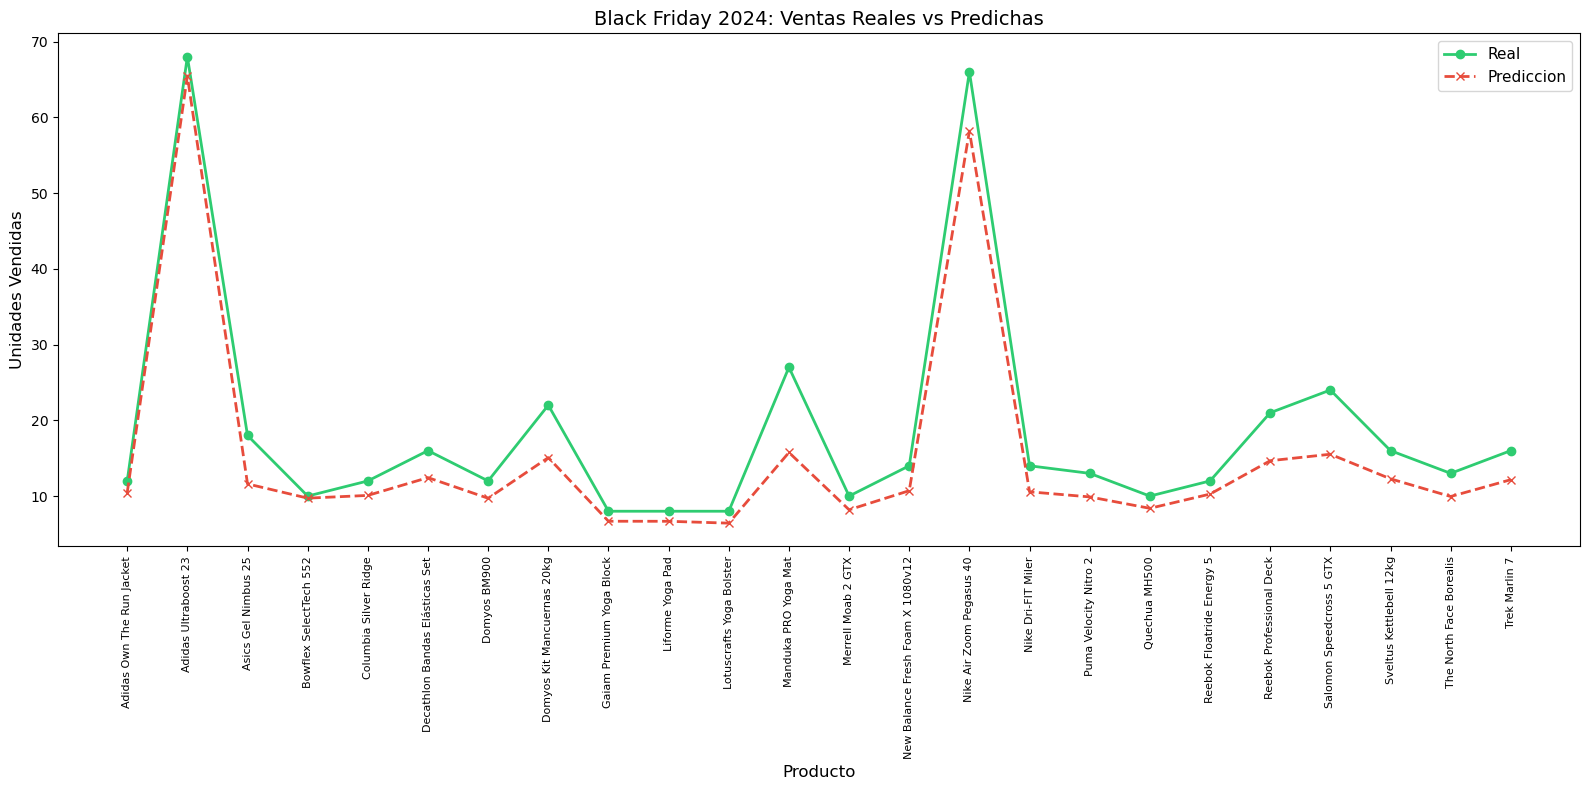

Top 10 Productos con Mayor Error:
                        nombre  unidades_vendidas  prediccion     error
          Manduka PRO Yoga Mat                 27   15.757359 11.242641
      Salomon Speedcross 5 GTX                 24   15.522166  8.477834
      Nike Air Zoom Pegasus 40                 66   58.173310  7.826690
    Domyos Kit Mancuernas 20kg                 22   15.077750  6.922250
           Asics Gel Nimbus 25                 18   11.606934  6.393066
      Reebok Professional Deck                 21   14.668591  6.331409
                 Trek Marlin 7                 16   12.164508  3.835492
       Sveltus Kettlebell 12kg                 16   12.278711  3.721289
Decathlon Bandas Elásticas Set                 16   12.436797  3.563203
            Nike Dri-FIT Miler                 14   10.563189  3.436811


In [36]:
# Analisis de Black Friday 2024
# Black Friday 2024 fue el 29 de noviembre

black_friday = validation_df[(validation_df["mes"] == 11) & (validation_df["dia"] == 29)].copy()

print(f"Registros en Black Friday: {len(black_friday)}")
print(f"Productos unicos: {black_friday['nombre'].nunique()}")

# Predicciones para Black Friday
X_bf = black_friday[feature_cols]
y_actual_bf = black_friday[target].values
y_pred_bf = model.predict(X_bf)

black_friday["prediccion"] = y_pred_bf
black_friday["error"] = np.abs(y_actual_bf - y_pred_bf)

# Calcular metricas generales
mae_bf = mean_absolute_error(y_actual_bf, y_pred_bf)
rmse_bf = np.sqrt(mean_squared_error(y_actual_bf, y_pred_bf))
print(f"MAE: {mae_bf:.2f}")
print(f"RMSE: {rmse_bf:.2f}")

# Ordenar por producto para grafico
bf_sorted = black_friday.sort_values("nombre").reset_index(drop=True)

# Grafico Real vs Predicho
plt.figure(figsize=(16, 8))
x = range(len(bf_sorted))
plt.plot(x, bf_sorted[target], label="Real", marker="o", linewidth=2, markersize=6, color="#2ecc71")
plt.plot(x, bf_sorted["prediccion"], label="Prediccion", marker="x", linewidth=2, markersize=6, color="#e74c3c", linestyle="--")

plt.title("Black Friday 2024: Ventas Reales vs Predichas", fontsize=14)
plt.xlabel("Producto", fontsize=12)
plt.ylabel("Unidades Vendidas", fontsize=12)
plt.xticks(x, bf_sorted["nombre"], rotation=90, fontsize=8)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Top 10 productos con mayor error
top_errors = bf_sorted.nlargest(10, "error")[["nombre", target, "prediccion", "error"]]
print("Top 10 Productos con Mayor Error:")
print(top_errors.to_string(index=False))

In [37]:
# Modelo final entrenado con TODOS los datos historicos (2021-2024)
print("=== ENTRENAMIENTO MODELO FINAL CON DATOS COMPLETOS ===")
print(f"Total registros para entrenamiento: {len(df)}")
print(f"Periodo: {df['fecha'].min()} hasta {df['fecha'].max()}")

# Features (mismas que antes)
target = 'unidades_vendidas'
exclude_cols = ['fecha', 'ingresos', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'nombre_dia']
feature_cols = [col for col in df.columns if col not in exclude_cols and col != target]

print(f"Features utilizadas: {len(feature_cols)}")
print(feature_cols)

# Entrenar con TODOS los datos
X_full = df[feature_cols]
y_full = df[target]

model_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=500,
    max_depth=6,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42
)

model_final.fit(X_full, y_full)

print(f"Modelo entrenado con {len(df)} registros")
print("Modelo listo para predicciones finales")

=== ENTRENAMIENTO MODELO FINAL CON DATOS COMPLETOS ===
Total registros para entrenamiento: 2880
Periodo: 2021-11-01 00:00:00 hasta 2024-11-30 00:00:00
Features utilizadas: 74
['precio_base', 'es_estrella', 'precio_venta', 'año', 'mes', 'dia', 'dia_semana', 'es_black_friday', 'dia_mes', 'semana_del_año', 'trimestre', 'dia_del_año', 'es_fin_semana', 'es_festivo', 'es_cyber_monday', 'es_comienzo_mes', 'es_fin_mes', 'es_primer_lunes_mes', 'es_rebajas', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'rolling_mean_7', 'descuento_pct', 'precio_competencia', 'ratio_precio', 'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridge', 'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900', 'nombre_h_Domyos Kit Mancuernas 20kg', 'nombre_h_Gaiam Premium Yoga Block', 'nombre_h_Liforme Yoga Pad', 'nombre_h_Lotuscrafts Yoga Bolster', 'nombre_h_Manduka PRO Yoga Ma

=== PERMUTATION IMPORTANCE ===

=== Importancia de Variables (Permutation) ===
                                  feature  importance_mean  importance_std
                              es_estrella         0.000000    0.000000e+00
                                      mes         0.000000    0.000000e+00
                                trimestre         0.000000    0.000000e+00
                          es_cyber_monday         0.000000    0.000000e+00
                            es_fin_semana         0.000000    0.000000e+00
                               es_festivo         0.000000    0.000000e+00
                                  dia_mes         0.000000    0.000000e+00
                               es_fin_mes         0.000000    0.000000e+00
       nombre_h_Adidas Own The Run Jacket         0.000000    0.000000e+00
                               es_rebajas         0.000000    0.000000e+00
                      es_primer_lunes_mes         0.000000    0.000000e+00
               subcat

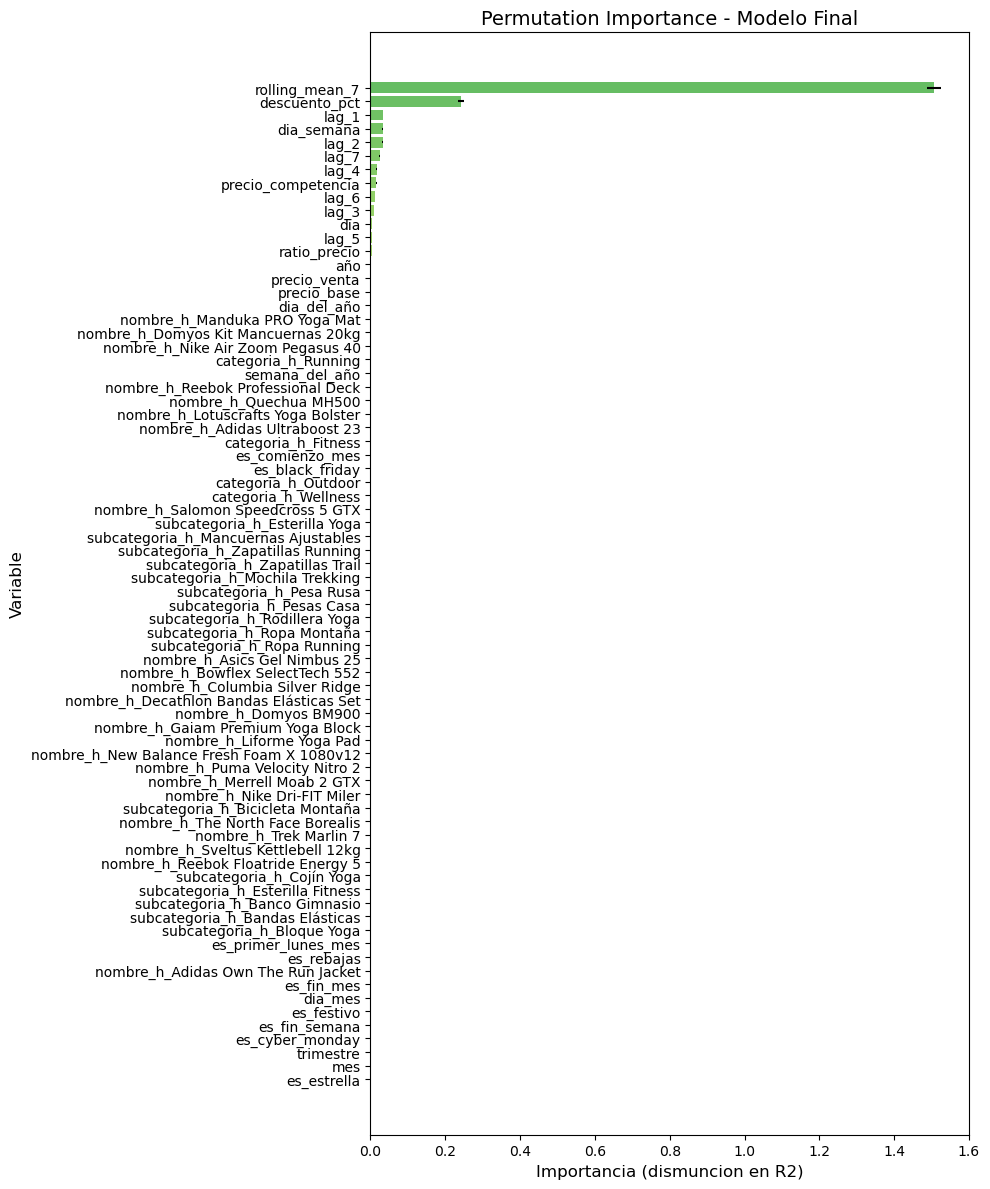


Modelo guardado en: ../models/modelo_final.joblib


In [38]:
# Permutation Importance con el modelo final
from sklearn.inspection import permutation_importance
import os

print("=== PERMUTATION IMPORTANCE ===")

# Calcular permutation importance (usando validacion para evitar overfitting)
perm_importance = permutation_importance(model_final, X_full, y_full, n_repeats=10, random_state=42, n_jobs=-1)

# Crear DataFrame con resultados
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=True)

print("\n=== Importancia de Variables (Permutation) ===")
print(importance_df.to_string(index=False))

# Grafico de barras horizontales
plt.figure(figsize=(10, 12))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importance_df)))
plt.barh(importance_df['feature'], importance_df['importance_mean'], 
        xerr=importance_df['importance_std'], color=colors)
plt.xlabel("Importancia (dismuncion en R2)", fontsize=12)
plt.ylabel("Variable", fontsize=12)
plt.title("Permutation Importance - Modelo Final", fontsize=14)
plt.tight_layout()
plt.show()

# Guardar modelo
os.makedirs("../models", exist_ok=True)
import joblib
joblib.dump(model_final, "../models/modelo_final.joblib")
print("\nModelo guardado en: ../models/modelo_final.joblib")
